# Test CR and CRk Gates on Quantum Inspire (Zebra)

This notebook characterizes the **CR(θ)** and **CRk(k)** two-qubit gates available on Quantum Inspire hardware.

**CR(θ)** = Controlled-Ry(θ): rotates the target qubit by θ around Y conditioned on the control being |1⟩.  
**CRk(k)** = Controlled phase rotation by 2π/2^k (used in QFT circuits).

We test both gates for a range of angles/k values to understand:
1. The actual rotation induced
2. Whether the gate is available natively on the backend
3. The behavior matches our ansatz design assumptions

## 1. Import Required Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from collections import Counter

from qiskit import QuantumCircuit, transpile
from qiskit.quantum_info import Statevector
from qiskit_quantuminspire.qi_provider import QIProvider

print("Libraries loaded.")

Libraries loaded.


In [2]:
! qi login "https://api.quantum-inspire.com"

Please continue logging in by opening: https://auth.quantum-inspire.com/activate?user_code=JCGL-DSNZ in your browser
If promped to verify a code, please confirm it is as follows: JCGL-DSNZ
Login successful!
Using member ID 111
Login successful!
Using member ID 111


## 2. Configure Quantum Inspire Backend

In [6]:
# Login and select Zebra backend
# Run: qi login "https://api.quantum-inspire.com" in terminal first
provider = QIProvider()



BACKEND_NAME = "Tuna-17"   # ← change if needed
backend = provider.get_backend(BACKEND_NAME)
print(f"  Qubits    : {backend.num_qubits}")


  Qubits    : 17


In [7]:
SHOTS     = 2048
# Connectivity on Zebra: (0,1) and (1,2)
CONTROL_Q = 0
TARGET_Q  = 1

# Angles to test for CR(θ)
CR_ANGLES = [np.pi/8, np.pi/4, np.pi/2, 3*np.pi/4, np.pi]

# k values to test for CRk  (gate angle = 2π / 2^k)
CRK_VALUES = [1, 2, 3, 4, 5]

print(f"CR  angles : {[f'{a/np.pi:.3f}π' for a in CR_ANGLES]}")
print(f"CRk k vals : {CRK_VALUES}  → angles {[f'2π/2^{k}={2*np.pi/2**k/np.pi:.4f}π' for k in CRK_VALUES]}")

CR  angles : ['0.125π', '0.250π', '0.500π', '0.750π', '1.000π']
CRk k vals : [1, 2, 3, 4, 5]  → angles ['2π/2^1=1.0000π', '2π/2^2=0.5000π', '2π/2^3=0.2500π', '2π/2^4=0.1250π', '2π/2^5=0.0625π']


## 3. Build CR Gate Test Circuits

**CR(θ)** = Controlled-Ry(θ): when control=|1⟩, rotates target by θ around Y.

We test two input states:
- `|10⟩` (control=1, target=0): CR(θ) should rotate target → expect |1⟩ component on target
- `|00⟩` (control=0, target=0): CR(θ) should do nothing

For control=|1⟩, the expected target state is `cos(θ/2)|0⟩ + sin(θ/2)|1⟩`,
so P(target=1) = sin²(θ/2).

**Statevector simulation is run locally first** to verify circuits before sending to hardware.

In [8]:
def build_cr_circuit(theta: float, control: int = 0, target: int = 1,
                     n_qubits: int = 3, init_control_one: bool = True) -> QuantumCircuit:
    """
    CR(theta) test circuit.

    If init_control_one=True:  prepare control=|1> then apply CR(theta).
      Expected P(target=1) = sin^2(theta/2)
    If init_control_one=False: control=|0>, CR(theta) should be identity on target.
      Expected P(target=1) = 0
    """
    qc = QuantumCircuit(n_qubits, 2)   # measure only control and target
    if init_control_one:
        qc.x(control)          # flip control to |1>
    # CR(theta) = controlled-Ry(theta) = cry in Qiskit
    qc.cry(theta, control, target)
    qc.measure(control, 0)
    qc.measure(target, 1)
    return qc


# Build all CR circuits and preview statevector expectations
print("CR(θ) circuits with control=|1⟩:")
print(f"{'θ':>12}  {'Expected P(t=1)':>17}  {'Sim P(t=1)':>12}")
print("-" * 46)
cr_circuits = []
for theta in CR_ANGLES:
    qc = build_cr_circuit(theta, CONTROL_Q, TARGET_Q)
    sv = Statevector(qc.remove_final_measurements(inplace=False))
    # probability that target qubit (index TARGET_Q) is |1>
    probs = sv.probabilities_dict()
    p1_target = sum(v for bitstr, v in probs.items() if bitstr[-(TARGET_Q+1)] == '1')
    expected = np.sin(theta / 2) ** 2
    print(f"{theta/np.pi:>10.3f}π  {expected:>17.4f}  {p1_target:>12.4f}")
    cr_circuits.append(qc)

print(f"\nTotal CR circuits: {len(cr_circuits)}")
print("\nExample circuit (θ=π/2):")
print(cr_circuits[CR_ANGLES.index(np.pi/2)])

CR(θ) circuits with control=|1⟩:
           θ    Expected P(t=1)    Sim P(t=1)
----------------------------------------------
     0.125π             0.0381        0.0381
     0.250π             0.1464        0.1464
     0.500π             0.5000        0.5000
     0.750π             0.8536        0.8536
     1.000π             1.0000        1.0000

Total CR circuits: 5

Example circuit (θ=π/2):
     ┌───┐           ┌─┐   
q_0: ┤ X ├─────■─────┤M├───
     └───┘┌────┴────┐└╥┘┌─┐
q_1: ─────┤ Ry(π/2) ├─╫─┤M├
          └─────────┘ ║ └╥┘
q_2: ─────────────────╫──╫─
                      ║  ║ 
c: 2/═════════════════╩══╩═
                      0  1 


## 4. Build CRk Gate Test Circuits

**CRk(k)** = Controlled phase rotation by angle `2π/2^k`.  
Unlike CR(θ), CRk adds a **phase** to |11⟩ — it is **diagonal** and doesn't mix amplitudes.

To see its effect, we put the control into superposition with H first:
- Prepare: `H|0⟩ ⊗ |0⟩` → `(|0⟩+|1⟩)/√2 ⊗ |0⟩`  
- Apply: CRk(k) → phases |11⟩ by `e^{i·2π/2^k}`
- Measure in X-basis (H before measure on control) to reveal the phase

This is the standard QFT gadget test.

In [9]:
def build_crk_circuit(k: int, control: int = 0, target: int = 1,
                      n_qubits: int = 3) -> QuantumCircuit:
    """
    CRk(k) test circuit.

    Circuit: H(control) → X(target) → CRk(k) → H(control) → measure both
    When target=|1>, CRk phases |1>|1> by e^{i*2pi/2^k}.
    After final H on control:
      P(control=0) = cos^2(pi/2^k)
      P(control=1) = sin^2(pi/2^k)
    """
    angle = 2 * np.pi / (2 ** k)  # = 2pi/2^k
    qc = QuantumCircuit(n_qubits, 2)
    qc.h(control)          # superposition on control
    qc.x(target)           # target = |1> so CRk has something to phase
    # CRk(k) = cp(2pi/2^k) in Qiskit  (controlled phase)
    qc.cp(angle, control, target)
    qc.h(control)          # measure in X-basis to reveal phase
    qc.measure(control, 0)
    qc.measure(target, 1)
    return qc


print("CRk(k) circuits:")
print(f"{'k':>4}  {'angle':>12}  {'Expected P(ctrl=1)':>20}  {'Sim P(ctrl=1)':>15}")
print("-" * 58)
crk_circuits = []
for k in CRK_VALUES:
    angle = 2 * np.pi / (2 ** k)
    qc = build_crk_circuit(k, CONTROL_Q, TARGET_Q)
    sv = Statevector(qc.remove_final_measurements(inplace=False))
    probs = sv.probabilities_dict()
    p1_ctrl = sum(v for bitstr, v in probs.items() if bitstr[-(CONTROL_Q+1)] == '1')
    expected = np.sin(np.pi / 2**k) ** 2
    print(f"{k:>4}  {angle/np.pi:>10.4f}π  {expected:>20.4f}  {p1_ctrl:>15.4f}")
    crk_circuits.append(qc)

print(f"\nTotal CRk circuits: {len(crk_circuits)}")
print("\nExample circuit (k=1, angle=π):")
print(crk_circuits[0])

CRk(k) circuits:
   k         angle    Expected P(ctrl=1)    Sim P(ctrl=1)
----------------------------------------------------------
   1      1.0000π                1.0000           1.0000
   2      0.5000π                0.5000           0.5000
   3      0.2500π                0.1464           0.1464
   4      0.1250π                0.0381           0.0381
   5      0.0625π                0.0096           0.0096

Total CRk circuits: 5

Example circuit (k=1, angle=π):
     ┌───┐       ┌───┐┌─┐
q_0: ┤ H ├─■─────┤ H ├┤M├
     ├───┤ │P(π) └┬─┬┘└╥┘
q_1: ┤ X ├─■──────┤M├──╫─
     └───┘        └╥┘  ║ 
q_2: ──────────────╫───╫─
                   ║   ║ 
c: 2/══════════════╩═══╩═
                   1   0 


## 5. Execute Circuits on Quantum Inspire

Send all CR and CRk circuits to the Zebra backend. We transpile first to ensure gate compatibility.

In [10]:
all_circuits  = cr_circuits + crk_circuits
circuit_labels = ([f"CR θ={a/np.pi:.3f}π" for a in CR_ANGLES] +
                  [f"CRk k={k}" for k in CRK_VALUES])

# Transpile for the backend
print("Transpiling circuits...")
tqcs = transpile(all_circuits, backend=backend, optimization_level=1)
print(f"  {len(tqcs)} circuits ready")

# Submit as a single batch job
print(f"Submitting to {BACKEND_NAME} ({SHOTS} shots each)...")
job = backend.run(tqcs, shots=SHOTS, memory=True)
print(f"  Job ID: {job.job_id()}")
print("  Waiting for results...")

Transpiling circuits...
  10 circuits ready
Submitting to Tuna-17 (2048 shots each)...
  Job ID: 
  Waiting for results...


In [11]:
# Retrieve results (blocks until job finishes)
result = job.result(timeout=600)

# Extract per-circuit counts
all_counts = []
for i in range(len(all_circuits)):
    counts = result.get_counts(i)
    all_counts.append(counts)
    print(f"[{i:2d}] {circuit_labels[i]:20s}  counts: {dict(sorted(counts.items()))}")


[ 0] CR θ=0.125π           counts: {'00': 107, '01': 1691, '10': 109, '11': 141}
[ 1] CR θ=0.250π           counts: {'00': 136, '01': 1487, '10': 108, '11': 317}
[ 2] CR θ=0.500π           counts: {'00': 103, '01': 861, '10': 182, '11': 902}
[ 3] CR θ=0.750π           counts: {'00': 84, '01': 292, '10': 154, '11': 1518}
[ 4] CR θ=1.000π           counts: {'00': 51, '01': 53, '10': 162, '11': 1782}
[ 5] CRk k=1               counts: {'00': 29, '01': 71, '10': 38, '11': 1910}
[ 6] CRk k=2               counts: {'00': 87, '01': 63, '10': 1772, '11': 126}
[ 7] CRk k=3               counts: {'00': 77, '01': 64, '10': 1773, '11': 134}
[ 8] CRk k=4               counts: {'00': 98, '01': 67, '10': 1769, '11': 114}
[ 9] CRk k=5               counts: {'00': 107, '01': 67, '10': 1716, '11': 158}


## 6. Visualize and Analyze Results

Compare measured probabilities against theoretical predictions for both CR and CRk gates.

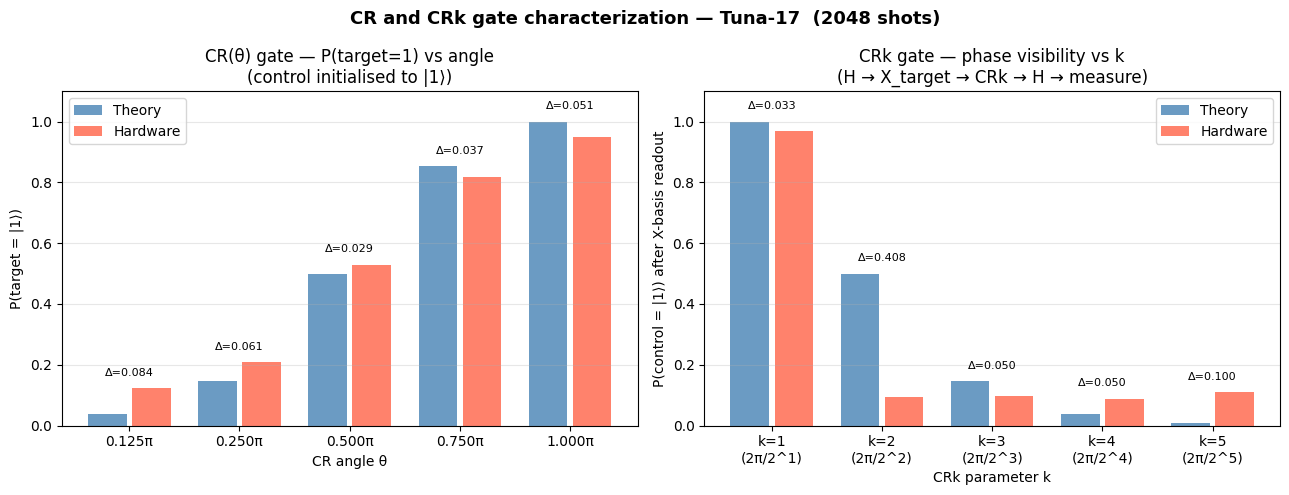

Figure saved: cr_crk_characterization.png


In [12]:
def get_p_target1(counts: dict, target_bit: int, shots: int) -> float:
    """Fraction of shots where target qubit measured as |1>."""
    # Qiskit bitstring: rightmost bit = qubit 0
    total = sum(counts.values())
    p1 = sum(v for bs, v in counts.items() if bs[-(target_bit + 1)] == '1') / total
    return p1

# ── CR gate analysis ──────────────────────────────────────────────────────────
cr_counts  = all_counts[:len(CR_ANGLES)]
cr_p1_meas = [get_p_target1(c, TARGET_Q, SHOTS) for c in cr_counts]
cr_p1_theo = [np.sin(a / 2) ** 2 for a in CR_ANGLES]

# ── CRk gate analysis ─────────────────────────────────────────────────────────
crk_counts  = all_counts[len(CR_ANGLES):]
crk_p1_meas = [get_p_target1(c, CONTROL_Q, SHOTS) for c in crk_counts]
crk_p1_theo = [np.sin(np.pi / 2**k) ** 2 for k in CRK_VALUES]

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# CR(θ) plot
ax = axes[0]
theta_labels = [f"{a/np.pi:.3f}π" for a in CR_ANGLES]
x = np.arange(len(CR_ANGLES))
ax.bar(x - 0.2, cr_p1_theo, 0.35, label="Theory", color="steelblue", alpha=0.8)
ax.bar(x + 0.2, cr_p1_meas, 0.35, label="Hardware", color="tomato",   alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(theta_labels)
ax.set_xlabel("CR angle θ")
ax.set_ylabel("P(target = |1⟩)")
ax.set_title("CR(θ) gate — P(target=1) vs angle\n(control initialised to |1⟩)")
ax.set_ylim(0, 1.1)
ax.legend()
ax.grid(axis="y", alpha=0.3)

# Annotate deviation
for xi, (theo, meas) in enumerate(zip(cr_p1_theo, cr_p1_meas)):
    ax.text(xi, max(theo, meas) + 0.04, f"Δ={abs(meas-theo):.3f}",
            ha="center", fontsize=8, color="black")

# CRk plot
ax = axes[1]
k_labels = [f"k={k}\n(2π/2^{k})" for k in CRK_VALUES]
x = np.arange(len(CRK_VALUES))
ax.bar(x - 0.2, crk_p1_theo, 0.35, label="Theory", color="steelblue", alpha=0.8)
ax.bar(x + 0.2, crk_p1_meas, 0.35, label="Hardware", color="tomato",   alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(k_labels)
ax.set_xlabel("CRk parameter k")
ax.set_ylabel("P(control = |1⟩) after X-basis readout")
ax.set_title("CRk gate — phase visibility vs k\n(H → X_target → CRk → H → measure)")
ax.set_ylim(0, 1.1)
ax.legend()
ax.grid(axis="y", alpha=0.3)

for xi, (theo, meas) in enumerate(zip(crk_p1_theo, crk_p1_meas)):
    ax.text(xi, max(theo, meas) + 0.04, f"Δ={abs(meas-theo):.3f}",
            ha="center", fontsize=8, color="black")

fig.suptitle(f"CR and CRk gate characterization — {BACKEND_NAME}  ({SHOTS} shots)",
             fontsize=13, fontweight="bold")
fig.tight_layout()
plt.savefig("cr_crk_characterization.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved: cr_crk_characterization.png")

In [13]:
# Summary table
print("=" * 65)
print("CR(θ) SUMMARY")
print(f"{'θ':>12}  {'Theory':>8}  {'Hardware':>10}  {'Error':>8}  {'Pass?':>6}")
print("-" * 65)
for theta, theo, meas in zip(CR_ANGLES, cr_p1_theo, cr_p1_meas):
    err = abs(meas - theo)
    ok  = "✓" if err < 0.05 else "✗"
    print(f"{theta/np.pi:>10.3f}π  {theo:>8.4f}  {meas:>10.4f}  {err:>8.4f}  {ok:>6}")

print()
print("CRk(k) SUMMARY")
print(f"{'k':>4}  {'Theory':>8}  {'Hardware':>10}  {'Error':>8}  {'Pass?':>6}")
print("-" * 45)
for k, theo, meas in zip(CRK_VALUES, crk_p1_theo, crk_p1_meas):
    err = abs(meas - theo)
    ok  = "✓" if err < 0.05 else "✗"
    print(f"{k:>4}  {theo:>8.4f}  {meas:>10.4f}  {err:>8.4f}  {ok:>6}")

print()
print("NOTE: CR(θ) is a controlled-Ry (amplitude rotation) — good for smooth ansatz.")
print("      CRk(k) is a controlled phase gate (diagonal) — useful for QFT, not GHZ prep.")

CR(θ) SUMMARY
           θ    Theory    Hardware     Error   Pass?
-----------------------------------------------------------------
     0.125π    0.0381      0.1221    0.0840       ✗
     0.250π    0.1464      0.2075    0.0611       ✗
     0.500π    0.5000      0.5293    0.0293       ✓
     0.750π    0.8536      0.8164    0.0371       ✓
     1.000π    1.0000      0.9492    0.0508       ✗

CRk(k) SUMMARY
   k    Theory    Hardware     Error   Pass?
---------------------------------------------
   1    1.0000      0.9673    0.0327       ✓
   2    0.5000      0.0923    0.4077       ✗
   3    0.1464      0.0967    0.0498       ✓
   4    0.0381      0.0884    0.0503       ✗
   5    0.0096      0.1099    0.1003       ✗

NOTE: CR(θ) is a controlled-Ry (amplitude rotation) — good for smooth ansatz.
      CRk(k) is a controlled phase gate (diagonal) — useful for QFT, not GHZ prep.
